# <u>Ridge, Lasso & Elastic Net Regression</u>

### Prerequisites:
* <a href="../2.Multiple%20linear%20Regression/Multiple%20linear%20Regression.ipynb">Check out the notebook on Multiple linear Regression</a>

## Topics

* [Review OLS derivation for Multiple linear Regression](#review)

* [0. Problem with unregularized multiple linear regression](#problem)
    
* [1. Ridge Regression](#ridge)
    * [1.1 Derivation](#derive1)
    * [1.2 Geometry of Ridge Regression](#geom)
    * [1.3 Implementation](#implement1)

* [2. Lasso Regression](#lasso)
    * [2.1 Derivation](#derive2)
    * [2.2 Geometry of Lasso Regression](#geom2)
    * [2.3 Implementation](#implement2)

* [3. Lasso vs Ridge Regression](#lasso)
    * [3.1 L1 Penalty vs L2 Penalty](#L1L2)
    * [3.2 Sparsity vs Shrinkage](#sparsevsshrink)
    * [3.3 Visualizations](#vision)

* [4. Elastic Net Regression](#lasso)
    * [4.1 Motivation](#motivation1)
    * [4.2 Formula](#derive1)
    * [4.3 Implementation](#implement1)

* [5. Robust linear Regression](#robust)

In [87]:
from sklearn.linear_model import Ridge # library for Ridge Regression taking a fixed lambda value
from sklearn.linear_model import RidgeCV # library for Ridge Regression taking an array of lambda values and chooses the best one
import statsmodels.api as sm # library for Ridge Regression with statistical inference
import numpy as np # for random numbers and matrix calculus
import plotly.graph_objects as go # interactive 3D plots but more complex
import plotly.express as px # also for interactive 3D plots but more simple
import matplotlib.pyplot as plt # for plotting (mainly 2D)
import pandas as pd # for working with dataframes
from scipy.optimize import minimize # to solve optimization problems (i.e. find parameter vector that minimzes some function but also fulfills a secondary condition)

<a class="anchor" id="review"></a>
## Review OLS derivation for Multiple linear Regression

In multiple linear regression, we model the relationship between a response variable $y$ and $p$ predictors $X \in \mathbb{R}^{n \times (p+1)}$ using 

$$
y=X\theta + \varepsilon \Leftrightarrow 
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix} =
\begin{pmatrix}
1 & x_1^{(1)} & \ldots & x_p^{(1)} \\
1 & x_1^{(2)} & \ldots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(n)} & \ldots & x_p^{(n)}
\end{pmatrix}
\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{pmatrix} +
\begin{pmatrix}
\varepsilon^{(1)} \\
\varepsilon^{(2)} \\
\vdots \\
\varepsilon^{(n)}
\end{pmatrix}
$$

We then estimate $\theta$ with $\hat{\theta}$ to make predictions for new data 
$$
\hat{y}=X \hat{\theta}
$$

We can derive the ordinary least squares (OLS) estimator in three ways:
1. Analytical solution (set derivative to 0 and solve)
2. Bayesian statistics
3. Optimization (Gradient Descent)



<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Analytical solution</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p+1}$ by finding parameter vector $\theta \in \mathbb{R}^{p+1}$
that minizes sum of squared errors.

$$
\begin{align*}
\hat{\theta} 
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} \lVert y - X\theta \rVert_2^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} (y-X\theta)^\top(y-X\theta) \\
&= \frac{\partial}{\partial \theta}  (y - X\theta)^\top (y - X\theta) \\
&= \frac{\partial}{\partial \theta} \left(y^\top y  - 2\theta^\top X^\top y + \theta^\top X^\top X\theta \right) \\
&=  - 2X^\top y + 2 X^\top X\theta 
\end{align*}
$$

Setting the derivative to 0 yields

$$
\begin{align*}
- 2X^\top y + 2 X^\top X\theta &= 0 \\ \Leftrightarrow
2 X^\top X\theta &= 2X^\top y \\ \Leftrightarrow
X^\top X\theta &= X^\top y \\ \Leftrightarrow
(X^\top X)^{-1}X^\top X\theta &= (X^\top X)^{-1}X^\top y \\ \Leftrightarrow
\theta &= (X^\top X)^{-1} X^\top y  \\
\Rightarrow \hat{\theta}_{\text{OLS}} &= (X^\top X)^{-1} X^\top y
\end{align*}
$$



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Bayesian statistics</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p+1}$ by finding parameter vector $\theta \in \mathbb{R}^{p+1}$
that maximizes the Posterior distribution $p(\theta \mid y,X)$ over $\theta$.

In the notebook Multiple linear Regression in section <a href="../2.Multiple%20linear%20Regression/Multiple%20linear%20Regression.ipynb#min">Core Minimization problem (OLS)</a> we derive the OLS solution using only the (log) likelihood $p(y \mid X ,\theta)$ but the true general setup includes a prior $p(\theta)$ quantifying our belief of how the true $\theta$ looks like before seeing any data. 

$$
\text{Likelihood: }y \mid X,\theta \sim \mathcal{N}(X\theta, \sigma^2\mathrm{I}_{n\times n}) \text{ since }\varepsilon \sim \mathcal{N}(0, \sigma^2\mathrm{I}_{n\times n}) \\

\text{Prior: } \theta \sim \mathcal{U}(-\infty,\infty)
$$

$$
\begin{align*}
\hat{\theta} 
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(\theta \mid y,X) \\
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} \frac{p(y \mid X,\theta)p(\theta)}{p(\mathcal{D})} 
\end{align*}
$$ 

- $\mathcal{D}=\left\{ \left( (x_1^{(i)},x_2^{(i)}, \ldots, x_p^{(i)}),y^{(i)} \right)\right\}_{i=1}^n$ i.i.d.
- $p(\mathcal{D})$ not dependent on $\theta$

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(y \mid X,\theta)p(\theta)
\end{align*}
$$ 

- $p(\theta) \propto 1$

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(y \mid X,\theta)
\end{align*}
$$ 

- Taking the logarithm of $p(y \mid X,\theta)$ make calculations more easily and does not change results 
- Also take i.i.d data into account

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} \log p(y \mid X,\theta) \\
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} -\frac{n}{2} \log (2\pi\sigma^2) - \frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)
\end{align*}
$$ 

- Since $-\frac{n}{2} \log (2\pi\sigma^2)$ and $\frac{1}{2\sigma^2}$ are independent from $\theta$ and multiplying with $-1$ means we no longer maximize but minimize we get

$$
\begin{align*}
&= \arg \min_{\theta \in \mathbb{R}^{p+1}}  (y-X\theta)^\top(y-X\theta) \\
&= \vdots \\
\Rightarrow \hat{\theta}_{\text{OLS}} &= (X^\top X)^{-1} X^\top y
\end{align*}
$$ 

</div>

</div>



<a class="anchor" id="problem"></a>
## 0. Problems with unregularized multiple linear regression

$$
\hat{\theta}=(X^\top X)^{-1} X^\top y
$$

**This estimator works well under ideal conditions, but in practice unregularized multiple linear regression suffers from several serious problems.**

$$
\begin{align*}
\text{Problems } &=
\left\{ 
\begin{array}{rcl}
\text{Case 1:} & \text{More features than observations } & p > n  \\ 
\text{Case 2:} & \text{Multicollinearity of features } & x_2 \approx 2 \cdot x_1 + \text{small noise}
\end{array}
\right\}
\end{align*}
$$

$$
\begin{align*}
\text{Consequence: } 
& - X^\top X \text{ becomes singular or nearly singular (rank}(X^\top X) < p\text{)} \\
& -\text{Estimated coefficients become very large and unstable} \\
& -\text{Small changes in data cause large changes in estimated coefficients} \\
& -\text{Since features are multicorrelated interpretations of their coefficients are difficult}
\end{align*}
$$

Note:
- Perfect multicollinearity = linear dependence
- Weak/Moderate multicollinearity = near linear dependence

| Case              | $X^TX$          | OLS                   |
| ----------------- | --------------- | --------------------- |
| Linear dependence | singular        | no unique solution    |
| Multicollinearity | nearly singular | unstable/large/non-interpretable coefficients |



#### Case 1A: Multicollinearity

In [2]:
# Case 1A: Multicollinearity
np.random.seed(1841)

n = 50

x1 = np.random.randn(n)
x2 = 2*x1 + 0.01*np.random.randn(n) # almost linear dependent

X = np.c_[np.ones(n), x1, x2]

true_theta = np.array([1, 2, -1])
y = X @ true_theta + 0.2*np.random.randn(n)

# OLS
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print("Estimated coefficients:", theta_hat)

# small noise change
y2 = y + 0.01*np.random.randn(n)
theta_hat2 = np.linalg.inv(X.T @ X) @ X.T @ y2
print("After tiny noise:", theta_hat2)

df_theta = pd.DataFrame({
    "theta_0": [theta_hat[0], theta_hat2[0]],
    "theta_1": [theta_hat[1], theta_hat2[1]],
    "theta_2": [theta_hat[2], theta_hat2[2]],
    "model": ["original fit", "tiny noise fit"]
})

fig = px.scatter_3d(
    df_theta,
    x="theta_0",
    y="theta_1",
    z="theta_2",
    color="model",
    size=[5,5]
)

fig.show()


# scatter points
fig = px.scatter_3d(x=x1, y=x2, z=y)

# grid for planes
grid = np.linspace(x1.min(), x1.max(), 20)
xx, yy = np.meshgrid(grid, grid)

# first plane
zz1 = theta_hat[0] + theta_hat[1]*xx + theta_hat[2]*yy

fig.add_surface(
    x=xx, y=yy, z=zz1,
    opacity=0.5,
    showlegend=True,
    showscale=False,
    name="Fit 1",
    colorscale='Blues'
)

# second plane (after tiny noise)
zz2 = theta_hat2[0] + theta_hat2[1]*xx + theta_hat2[2]*yy

fig.add_surface(
    x=xx, y=yy, z=zz2,
    opacity=0.5,
    showlegend=True,
    showscale=False,
    colorscale=[[0, 'red'], [1, 'red']],
    name="Fit 2 after tiny noise",
)

fig.show()

Estimated coefficients: [ 1.05444392  2.13444852 -1.06249901]
After tiny noise: [ 1.05456105  1.99082407 -0.99017981]


#### Case 1B: Perfect Multicollinearity = Linear dependence

Assume a linear dependence between features:
$$
x_2 = 2x_1
$$

---

**Model:**
$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2
$$

---

**Substitute the linear dependence:**
$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 (2x_1)
$$

---

**Simplify:**
$$
\hat{y} = \theta_0 + (\theta_1 + 2\theta_2)x_1
$$

---

**Key observation:**

The prediction depends only on the combination:
$$
\theta_1 + 2\theta_2
$$

---

**Non-uniqueness of the solution:**

Let $c \in \mathbb{R}$. Define a new parameter vector by adding/subtracting from $\theta_1$ and $\theta_2$:
$$
\theta_1'= \theta_1 + (-c)
$$

$$
(\theta_1 - c) + 2(\theta_2 + ?) \text{ and we want } (\theta_1 - c) + 2(\theta_2 + ?) = \theta_1 + 2\theta_2
$$

$$
\begin{align*}
(\theta_1 - c) + 2(\theta_2 + ?) &= \theta_1 + 2\theta_2 \\ \iff 
\theta_1 - c + 2\theta_2 + 2? &= \theta_1 + 2\theta_2 \\ \iff
 - c  + 2? &=  0 \\ \iff
2? &=  c \\ \iff
? &=  \frac{c}{2} \\ \Rightarrow \theta_2'= \theta_2 + \frac{c}{2}
\end{align*}
$$

---

**Check that predictions remain unchanged:**
$$
\theta_1' + 2\theta_2'
= (\theta_1 - c) + 2\left(\theta_2 + \frac{c}{2}\right)
= \theta_1 + 2\theta_2
$$

---

**Conclusion:**
$$
\hat{y}' = \hat{y}
$$

---

**Interpretation:**

- The model is not identifiable.
- Infinitely many parameter vectors yield the same predictions.
- Only $\theta_1$ and $\theta_2$ depend on $x_1$ so only those two can be changed.


In [3]:
# Case 1B: Perfect Multicollinearity = Linear dependence
np.random.seed(1950)

n = 50

x1 = np.random.randn(n)
x2 = 2*x1 # perfect linear dependence

X = np.c_[np.ones(n), x1, x2]

y = 1 + 2*x1 - 1*x2 + 0.1*np.random.randn(n)

# pseudo inverse (since inverse fails)
theta_hat = np.linalg.pinv(X) @ y

print("One valid solution:", theta_hat)

theta_alt = theta_hat.copy()
c = 16 # any number you want
theta_alt[1] -= c
theta_alt[2] += c/2 # keeps prediction identical

print("Alternative solution:", theta_alt)

print("Coefficients identical:",np.allclose(theta_hat,theta_alt))

print("Predictions identical:",np.allclose(X @ theta_hat, X @ theta_alt))

fig = px.scatter_3d(x=x1, y=x2, z=y)

# grid
grid = np.linspace(x1.min(), x1.max(), 20)
xx, yy = np.meshgrid(grid, grid)

# plane 1
zz1 = theta_hat[0] + theta_hat[1]*xx + theta_hat[2]*yy

fig.add_surface(
    x=xx,
    y=yy,
    z=zz1,
    opacity=0.5,
    name="plane 1",
    showscale=False,
    colorscale="Blues",
    showlegend=True
)

# plane 2
zz2 = theta_alt[0] + theta_alt[1]*xx + theta_alt[2]*yy

fig.add_surface(
    x=xx,
    y=yy,
    z=zz2,
    opacity=0.5,
    showscale=False,
    colorscale=[[0, 'red'], [1, 'red']],
    name="plane 2",
    showlegend=True
)

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-3, 3]),
        yaxis=dict(range=[-6, 6]),
        zaxis=dict(range=[0.9, 1.2])
    )
)

fig.show()

One valid solution: [ 0.98425934 -0.00146873 -0.00293746]
Alternative solution: [  0.98425934 -16.00146873   7.99706254]
Coefficients identical: False
Predictions identical: True


#### Case 2: More features than observations

We consider the case where the number of features exceeds the number of observations:

- $n = 3$ observations
- $p = 5$ features
- Design matrix $X \in \mathbb{R}^{3 \times 6}$ (including intercept)

---

**Linear model:**
$$
y = X \theta + \varepsilon
$$

Since $p+1 > n$, the system is **underdetermined**, i.e., there are infinitely many solutions $\theta$ that satisfy the data.

---

**Minimum-norm OLS solution using pseudo-inverse:**
$$
\hat{\theta} = X^+ y = X^T (X X^T)^+ y
$$

- $X^+$ is the Moore-Penrose pseudo-inverse
- This gives the **unique solution with minimal $| \theta |$** among all possibilities

---

**Alternative solutions:**

Let $v \in \mathbb{R}^{p+1}$ be any vector. We can construct an alternative solution as:

$$
\theta_\text{alt} = \hat{\theta} + \underbrace{v - X^T (X X^T)^+ (X v)}_{\in \text{ null space of } X}
$$

**Check predictions:**
$$
X \theta_\text{alt} = X \hat{\theta} + X \big(v - X^T (X X^T)^+ (X v)\big) = X \hat{\theta}
$$

&#9989; Predictions are identical, even though the coefficients differ.

---

**Connection to the null space:**

- The **null space of \(X\)** is:
$$
\text{null}(X) = \{ z \in \mathbb{R}^{p+1} : X z = 0 \}
$$

- Any vector in the null space **does not change predictions**
- Our alternative solution satisfies:
$$
v_\text{null} = v - X^T (X X^T)^+ (X v) \in \text{null}(X)
$$

- Therefore:
$$
\theta_\text{alt} = \hat{\theta} + v_\text{null}
$$

---

**Interpretation:**

- The system is **underdetermined**, so infinitely many coefficient vectors exist.
- All alternative solutions differ **only along the null space directions** of $X$.
- The pseudo-inverse solution $$\hat{\theta}$$ is the **minimum-norm solution**, while any addition along the null space keeps predictions unchanged.

In [4]:
# Case 2: More features than observations

np.random.seed(0)

n = 3
p = 5

X = np.random.randn(n, p) # design matrix with n rows and p columns and p > n
X = np.c_[np.ones(n), X] # add intercept column

theta_true = np.random.randn(p+1)

y = X @ theta_true + 0.3*np.random.randn(n)

theta_hat = np.linalg.pinv(X) @ y # use np.linalg.pinv(X) instead of np.linalg.inv(X.T @ X)
print("theta=",theta_hat)

v = np.random.randn(p+1) # random vector from standard normal distribution of lenght p+1

theta_alt = theta_hat + v - X.T @ np.linalg.pinv(X @ X.T) @ (X @ v) # alternative solution
print("alternative theta=",theta_alt)

print("Coefficients identical:",np.allclose(theta_hat, theta_alt))
print("Predictions identical:",np.allclose(X @ theta_hat, X @ theta_alt))

theta= [-0.92454478  0.71343054  0.01468797  0.58938041 -0.92772942 -1.14044788]
alternative theta= [-0.453877    0.47280069 -0.45530757  1.11945985 -0.76630576 -1.53596657]
Coefficients identical: False
Predictions identical: True


| Case              | What happens           |
| ----------------- | ---------------------- |
| Multicollinearity | coefficients unstable  |
| Linear dependence | infinite solutions     |
| $p > n$             | infinite solutions     |



<a class="anchor" id="ridge"></a>
## 1. Ridge Regression

<a class="anchor" id="derive1"></a>
## 1.1 Derivation


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Analytical solution</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p'}$ by finding parameter vector $\theta \in \mathbb{R}^{p'}$
that minizes sum of squared errors and <u>shrinks</u> size of coefficients $\theta_1,\ldots,\theta_p$ for $p'= p$ (number of features) (or $\theta_0,\theta_1,\ldots,\theta_p$ for $p'=p+1$;intercept included) via an $\ell_2$ penalty.

**Optimization problem**
$$
\begin{align*}
& \arg \min_{\theta \in \mathbb{R}^{p'}} & \lVert y - X\theta \rVert_2^2 \\
& \text{s.t.} & \lVert \theta \rVert_2^2 \le t   \\
& \iff & \lVert \theta \rVert_2^2 - t \le 0 
\end{align*}
$$

*small $t$ strong restriction $\rightarrow$ heavy shrinkage*

*large $t$ weak restriction $\rightarrow$ close to OLS*



**Lagrangian of optimization problem**

$$
\begin{align*}
\mathcal{L}(\theta,\lambda) 
&= \lVert y - X\theta \rVert_2^2 + \lambda (\lVert \theta \rVert_2^2 - t)  \\
&= (y - X\theta)^\top (y - X\theta) + \lambda (\theta^\top \theta - t) \\
&= y^\top y - y^\top X\theta - (X\theta)^\top y + (X\theta)^\top X\theta + \lambda \theta^\top\theta - \lambda t \\
&= y^\top y - y^\top X\theta - \theta^\top X^\top y + \theta^\top X^\top X\theta + \lambda \theta^\top\theta - \lambda t \\
&= y^\top y - 2\theta^\top X^\top y + \theta^\top X^\top X\theta + \lambda \theta^\top\theta - \lambda t \\
\end{align*}
$$

Take gradient and then set it to 0

$$
\begin{align*}
\nabla_\theta \mathcal{L}(\theta,\lambda) &=0 \\ \Leftrightarrow
- 2 X^\top y + 2X^\top X\theta + 2\lambda \theta  &=0 \\ \Leftrightarrow
- 2 (X^\top y - X^\top X\theta - \lambda \theta)  &=0 \hspace{1 mm} \mid \cdot (-0.5) \\ \Leftrightarrow
X^\top y - X^\top X\theta - \lambda \theta  &=0 \hspace{1 mm} \mid -X^\top y \\ \Leftrightarrow
 - X^\top X\theta - \lambda \theta  &=-X^\top y \hspace{1 mm} \mid \cdot (-1) \\ \Leftrightarrow
X^\top X\theta + \lambda \theta  &=X^\top y\\ \Leftrightarrow
(X^\top X + \lambda I)\theta  &=X^\top y \hspace{1 mm} \mid \cdot (X^\top X + \lambda \mathrm{I})^{-1} \\ \Leftrightarrow
\theta &=(X^\top X + \lambda \mathrm{I})^{-1}X^\top y  \\
\end{align*}
$$
$$
\Rightarrow \hat{\theta}_{\text{Ridge}} =(X^\top X + \lambda \mathrm{I}_{p'\times p'})^{-1}X^\top y 
\text{ for }X\in\mathbb{R}^{n \times p'}  
$$

<p align="center">
<img src="ridge_geom.jpg" width="500"/>
</p>

Relationship between $t$ and $\lambda$:
$$
t \uparrow \Rightarrow \lambda \downarrow 
$$
$$
t \downarrow \Rightarrow \lambda \uparrow
$$



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Bayesian statistics</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p'}$ by finding parameter vector $\theta \in \mathbb{R}^{p'}$
that maximizes the Posterior distribution $p(\theta \mid y,X)$ over $\theta$ with $p'=p$(number of features) or $p'=p+1$.



$$
\text{Likelihood: }y \mid X,\theta \sim \mathcal{N}(X\theta, \sigma^2\mathrm{I}_{n\times n}) \text{ since }\varepsilon \sim \mathcal{N}(0, \sigma^2\mathrm{I}_{n\times n}) \\

\text{Prior: } \theta \sim \mathcal{N}(\mu_0=0_{p'}, \tau^2\mathrm{I}_{p'\times p'}) 
$$

$$
\begin{align*}
\hat{\theta} 
&= \arg \max_{\theta \in \mathbb{R}^{p'}} p(\theta \mid y,X) \\
&= \arg \max_{\theta \in \mathbb{R}^{p'}} \frac{p(y \mid X,\theta)p(\theta)}{p(\mathcal{D})} 
\end{align*}
$$ 

- $\mathcal{D}=\left\{ \left( (x_1^{(i)},x_2^{(i)}, \ldots, x_p^{(i)}),y^{(i)} \right)\right\}_{i=1}^n$ 
- $p(\mathcal{D})$ not dependent on $\theta$

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p'}} p(y \mid X,\theta)p(\theta)
\end{align*}
$$ 


$$
\begin{align*}
p(y \mid X,\theta)
&=\frac{\exp\left(-\frac{1}{2} (y-X\theta)^\top (\sigma^2 \mathrm{I})^{-1}(y-X\theta)\right)}{(2\pi)^{n/2} \det(\sigma^2 \mathrm{I})^{1/2}} \\
&=\frac{\exp\left(-\frac{1}{2} (y-X\theta)^\top (\frac{1}{\sigma^2} \mathrm{I})(y-X\theta)\right)}{(2\pi)^{n/2} (\sigma^{2n})^{1/2}} \\
&=\frac{\exp\left(-\frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)\right)}{(2\pi)^{n/2} \sigma^{n}} \\
&=\frac{\exp\left(-\frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)\right)}{(2\pi \sigma^2)^{n/2}} \\
&=\underbrace{(2\pi \sigma^2)^{-n/2}}_{\text{constant}} \exp\left(-\frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)\right)\\
\end{align*} 
$$

---


$$
\begin{align*}
p(\theta)
&=\frac{\exp\left(-\frac{1}{2} (\theta-\mu_0)^\top (\tau^2 \mathrm{I})^{-1}(\theta-\mu_0)\right)}{(2\pi)^{p'/2} \det(\tau^2 \mathrm{I})^{1/2}} \\
&=\frac{\exp\left(-\frac{1}{2} (\theta-\mu_0)^\top (\frac{1}{\tau^2} \mathrm{I})(\theta-\mu_0)\right)}{(2\pi)^{p'/2} (\tau^{2p'})^{1/2}} \\
&=\frac{\exp\left(-\frac{1}{2\tau^2} (\theta-\mu_0)^\top(\theta-\mu_0)\right)}{(2\pi)^{p'/2} \tau^{p'}} \\
&=\frac{\exp\left(-\frac{1}{2\tau^2} (\theta-\mu_0)^\top(\theta-\mu_0)\right)}{(2\pi\tau^2)^{p'/2}} \\
&=\underbrace{(2\pi \tau^2)^{-p'/2}}_{\text{constant}} \exp\left(-\frac{1}{2\tau^2} (\theta-\mu_0)^\top(\theta-\mu_0)\right)\\
\end{align*} 
$$

---

- terms not depending on $\theta$ are constant with respect to $\theta$ and can be left out here
- Take the logarithm of both $p(y \mid X,\theta)$ and $p(\theta)$ for easier optimization

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p'}} \log p(y \mid X,\theta)p(\theta) \\
&= \arg \max_{\theta \in \mathbb{R}^{p'}} \log p(y \mid X,\theta) + \log p(\theta) \\
&= \arg \max_{\theta \in \mathbb{R}^{p'}} -\frac{1}{2\sigma^2} \lVert y-X\theta \rVert_2^2 -\frac{1}{2\tau^2} \lVert \theta-\mu_0 \rVert_2^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p'}} \frac{1}{2\sigma^2} \lVert y-X\theta \rVert_2^2 + \frac{1}{2\tau^2} \lVert \theta-\mu_0 \rVert_2^2 \\
&\text{multiply everything by }2\sigma^2 \text{ for notational convenience} \\
&= \arg \min_{\theta \in \mathbb{R}^{p'}}  \lVert y-X\theta \rVert_2^2 + \frac{\sigma^2}{\tau^2} \lVert \theta-\mu_0 \rVert_2^2 \\
&\hspace{2.5 cm} \text{denote }\lambda := \frac{\sigma^2}{\tau^2} \\
&= \arg \min_{\theta \in \mathbb{R}^{p'}}  \lVert y-X\theta \rVert_2^2 + \lambda \lVert \theta-\mu_0 \rVert_2^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p'}}  (y-X\theta)^\top (y-X\theta) + \lambda \underbrace{(\theta-\mu_0)^\top (\theta-\mu_0)}_{\theta^\top \theta - \theta^\top \mu_0 - \mu_0^\top \theta + \mu_0^\top \mu_0} \\
\end{align*}
$$ 

* Take gradient and set to 0 
- $- \theta^\top \mu_0 - \mu_0^\top \theta=- \theta^\top \mu_0 - \theta^\top \mu_0=-2\theta^\top \mu_0$

$$
\begin{align*}
-2X^\top y + 2 X^\top X\theta + 2\lambda \theta - 2\lambda\mu_0 &= 0 \hspace{1 mm} \mid \cdot 0.5\\
-X^\top y + X^\top X\theta + \lambda \theta - \lambda\mu_0 &= 0\\
X^\top X\theta + \lambda \theta &= X^\top y + \lambda\mu_0\\
(X^\top X + \lambda \mathrm{I})\theta &= X^\top y + \lambda\mu_0\\
\theta &= (X^\top X + \lambda \mathrm{I})^{-1} (X^\top y + \lambda\mu_0)\\
\end{align*}
$$ 

$$
\Rightarrow \hat{\theta}_{\text{Ridge}} =(X^\top X + \lambda \mathrm{I}_{p'\times p'})^{-1}X^\top y \\[2mm]
\text{ for }X\in\mathbb{R}^{n \times p'}, \mu_0 = 0 \text{ with }0 \in \mathbb{R}^{p'} \\[2mm] \text{ and }\lambda=\frac{\sigma^2}{\tau^2}=\frac{\text{data noise}}{\text{parameter uncertainty}}
$$

- $\lambda=\frac{\sigma^2}{\tau^2}$ is our relative trust in our prior belief about $\theta$
- small $\lambda$ means $\sigma^2 < \tau^2$ which means we have reliable data & unreliable prior beliefs and $\hat{\theta}_{\text{Ridge}}$ is close to $\hat{\theta}_{\text{OLS}}$ **(low shrinakge)**
- large $\lambda$ means $\sigma^2 > \tau^2$ which means we have ureliable data & reliable prior belief and $\hat{\theta}_{\text{Ridge}}$ is close to $\mu_0=0$ **(strong shrinakge)**
- If $\lambda=0$ then $\hat{\theta}_{\text{Ridge}}$ = $\hat{\theta}_{\text{OLS}}$ and $\hat{\theta}_{\text{Ridge}} \rightarrow \mu_0=0$ for $\lambda \rightarrow \infty$ 

</div>

</div>

&#129504; Now how does Ridge solve multicollinearity ? : $X^\top X$ can be non-invertible, but $X^\top X + \lambda \mathrm{I}$ is positive definite and invertible for $\lambda > 0$



```python
# 1. Ridge (scikit-learn)
from sklearn.linear_model import Ridge
model1 = Ridge(
    alpha=1.0,              # λ (regularization strength)
    fit_intercept=True,     # whether to estimate intercept θ0
    copy_X=True,            # copy X or overwrite
    max_iter=None,          # max iterations (only relevant for some solvers)
    tol=1e-4,               # convergence tolerance
    solver="auto",          # solver chosen automatically
    positive=False,         # force coefficients >= 0 if True
    random_state=None       # used for stochastic solvers
)

model1.fit(X, y) # fit model (solve Ridge optimization problem)

model1.coef_        # estimated slope coefficients θ1,...,θp (shape: (p,))
model1.intercept_   # estimated intercept θ0
model1.predict(X)   # predictions
model1.score(X, y)  # R^2 score
model1.n_features_in_   # number of features
model1.feature_names_in_  # feature names (if X is pandas DataFrame)


# 2. Ridge with Cross-Validation
model2 = RidgeCV(
    alphas=np.logspace(-3, 3, 100),  # candidate λ values
    fit_intercept=True,
    scoring=None,        # scoring metric (None = default R²)
    cv=None,             # None = efficient LOOCV (generalized CV)
    gcv_mode=None,       # mode for generalized CV
    store_cv_values=False,  # must be True to access cv_values_
    alpha_per_target=False  # separate λ per target (multi-output only)
)

model2.fit(X, y)  # fits model AND selects best λ

model2.alpha_      # best λ found via CV
model2.coef_       # coefficients
model2.intercept_  # intercept
model2.predict(X)  # predictions


# ⚠️ Only available if store_cv_values=True
model2.cv_values_  # shape: (n_samples, n_alphas)


import statsmodels.api as sm
X = sm.add_constant(X) # add intercept column
model3 = sm.OLS(y, X) # creates statsmodels.regression.linear_model.OLS object
results_ridge = model3.fit_regularized(alpha=1.0, L1_wt=0) # perfroms Regularization with lambda=1 and L2 penalty => Ridge Regression
results_ridge.params # estimated coefficients (intercept and slopes)
results_lasso = model3.fit_regularized(alpha=1.0, L1_wt=0) # perfroms Regularization with lambda=1 and L2 penalty => Lasso Regression

```

In [106]:
Ridge(alpha=1.0, # lambda value
                fit_intercept=True, # intercept column
                copy_X=True,
                max_iter=None,
                tol=0.0001,
                positive=False,
                random_state=None)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


<a class="anchor" id="geom1"></a>
## 1.2 Geometry of Ridge Regression

**Optimization problem**
$$
\begin{align*}
& \arg \min_{\theta \in \mathbb{R}^{p'}} & \lVert y - X\theta \rVert_2^2 \\
& \text{s.t.} & \lVert \theta \rVert_2 \le t   \\
\end{align*}
$$

theta_hat= [ 1.87741061 -0.68944138]  this vector minimizes the loss function and is inside the circle


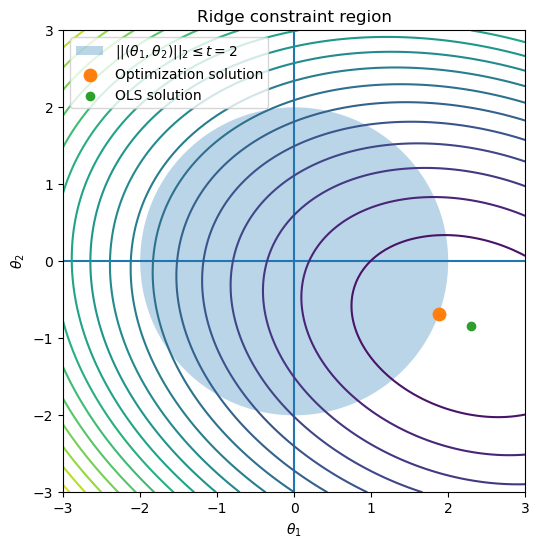

In [ ]:
np.random.seed(1126) # for reproducibility of random numbers

# data (NO intercept, 2 parameters)
n, p = 20, 2
X = np.random.randn(n, p)

theta_true = np.array([2.3, -0.8]) # true theta
y = X @ theta_true + 0.2*np.random.randn(n)

# constraint radius
t = 2.0

# objective function (we want to minimize this)
def objective(theta):
    return np.linalg.norm(y - X @ theta)**2

# constraint ||theta|| <= t
cons = ({
    'type': 'ineq', # since we have <= in ||theta|| <= t
    'fun': lambda theta: t - np.linalg.norm(theta) # with t - np.linalg.norm(theta) we can check wether theta is inside the circle 
    # alternative t**2 - np.dot(theta, theta)
})

theta0 = np.zeros(p) # start parameters

res = minimize(objective, theta0, constraints=cons)
#print(res,"\n")
theta_hat = res.x # extract resulting vector

print("theta_hat=", theta_hat," this vector minimizes the loss function and is inside the circle")


# Plot constraint circle
theta = np.linspace(0, 2*np.pi, 400)
theta1 = t * np.cos(theta)
theta2 = t * np.sin(theta)

plt.figure(figsize=(6,6))

# filled circle
plt.fill(theta1, theta2, alpha=0.3, label=f"$ || (\\theta_1,\\theta_2)||_2 \\leq t=2$")

# ridge/optimization solution
plt.scatter(theta_hat[0], theta_hat[1], s=80, label="Optimization solution")

plt.axhline(0)
plt.axvline(0)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Ridge constraint region")
plt.gca().set_aspect('equal')

# grid for contour
grid = np.linspace(-3, 3, 100)
xx, yy = np.meshgrid(grid, grid)

Z = np.zeros_like(xx)

for i in range(len(grid)):
    for j in range(len(grid)):
        theta_tmp = np.array([xx[i,j], yy[i,j]])
        Z[i,j] = np.linalg.norm(y - X @ theta_tmp)**2

# plot contours
plt.contour(xx, yy, Z, levels=20) # Each contour line connects all points 𝜃 that give the same error with 𝜃_OLS as center
# Moving towards center -> lower error
# Moving away -> higher error


theta_ols = np.linalg.pinv(X) @ y
plt.scatter(theta_ols[0], theta_ols[1], label="OLS solution")
plt.legend(loc=2)


plt.show()

**Lagrangian of the optimization problem**

$$
\hat{\theta}_{\text{Ridge}} =(X^\top X + \lambda \mathrm{I})^{-1}X^\top y
$$

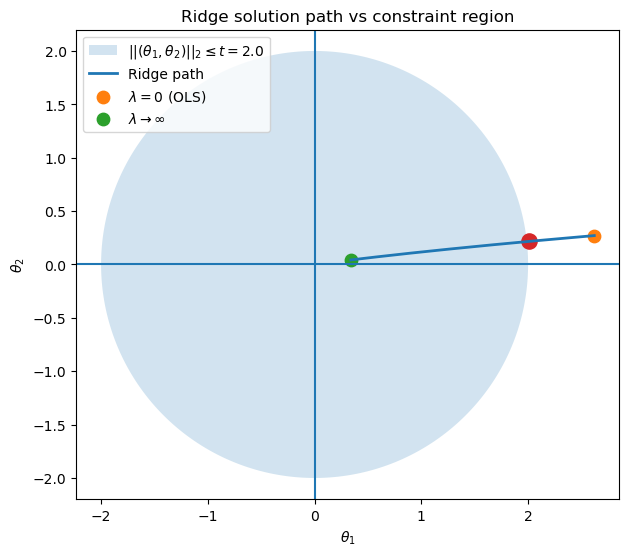

In [ ]:
np.random.seed(1127) # for reproducibility of random numbers

# data (NO intercept, 2 parameters)
n, p = 20, 2
X = np.random.randn(n, p)

theta_true = np.array([2.6, 0.3])
y = X @ theta_true + 0.2*np.random.randn(n)

# constraint radius
t = 2.0


# Ridge solutions for lambdas
lambdas = np.linspace(0, 100, 200) # different lambdas

theta_ridge = []

for lam in lambdas:
    theta = np.linalg.inv(X.T @ X + lam*np.eye(p)) @ X.T @ y
    theta_ridge.append(theta)

theta_ridge = np.array(theta_ridge)


# constraint circle
theta = np.linspace(0, 2*np.pi, 400)
theta1 = t * np.cos(theta)
theta2 = t * np.sin(theta)

plt.figure(figsize=(7,7))

# circle
plt.fill(theta1, theta2, alpha=0.2, label=f"$ || (\\theta_1,\\theta_2)||_2 \\leq t={t}$")

# ridge path
plt.plot(theta_ridge[:,0], theta_ridge[:,1],
         linewidth=2,
         label="Ridge path")

# mark lambda=0 (OLS)
plt.scatter(theta_ridge[0,0],
            theta_ridge[0,1],
            s=80,
            label=r"$\lambda=0$ (OLS)")

# mark large lambda
plt.scatter(theta_ridge[-1,0],
            theta_ridge[-1,1],
            s=80,
            label=r"$\lambda \to \infty$")

plt.axhline(0)
plt.axvline(0)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Ridge solution path vs constraint region")

plt.legend(loc=2)
plt.gca().set_aspect('equal')

norms = np.linalg.norm(theta_ridge, axis=1) # compute norms of theta_ridge solutions
idx = np.argmin(np.abs(norms - t)) # check for the one theta_ridge that has a norm closest to t

theta_t = theta_ridge[idx] # select that theta_ridge solution

plt.scatter(theta_t[0], theta_t[1],
            s=120,
            label=r"$||\theta|| \approx t$")

plt.show()

**Relationship between $t$ and $\lambda$**

* For every $t$, there exists a $\lambda$ 
* For every $\lambda$, there exists a $t$ 

<u>Steps</u>

1. solve Ridge for different $\lambda$

2. compute $\lVert \theta_{\text{Ridge}} \rVert$ for these different $\lambda$ values

3. pick the $\lVert \theta_{\text{Ridge}} \rVert$ closest to  $t$

Chosen norm: 1.9762381429746485
theta_hat: [1.96481852 0.21214474]
lambda used: 4.9770235643321135


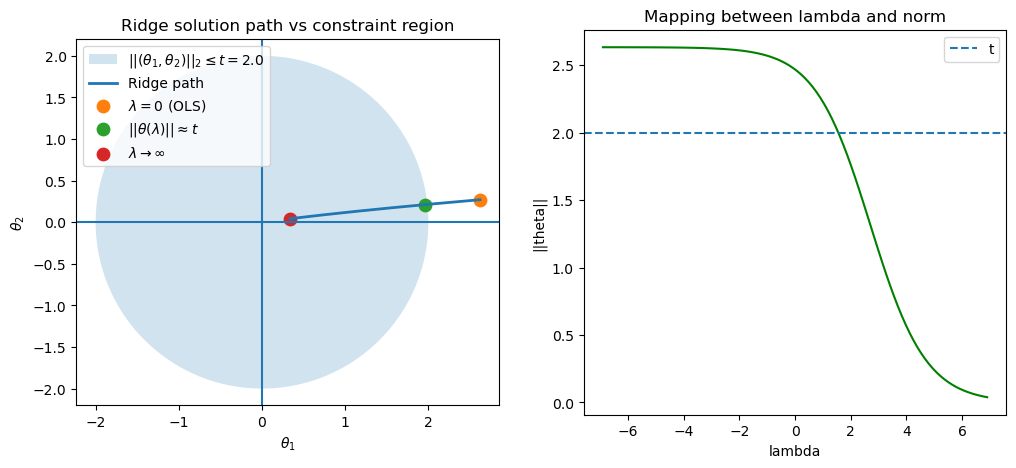

In [86]:
lambdas = np.logspace(-3, 3, 100)

solutions = []
norms = []

for lam in lambdas:
    theta = np.linalg.inv(X.T @ X + lam*np.eye(X.shape[1])) @ X.T @ y
    solutions.append(theta)
    norms.append(np.linalg.norm(theta))

# find closest to desired t
t = 2.0
idx = np.argmin(np.abs(np.array(norms) - t)) # find theta_ridge solution closest to t

theta_hat = solutions[idx]

print("Chosen norm:", norms[idx])
print("theta_hat:", theta_hat)
print("lambda used:", lambdas[idx])


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

# circle
plt.fill(theta1, theta2, alpha=0.2, label=f"$ || (\\theta_1,\\theta_2)||_2 \\leq t={t}$")

# ridge path
plt.plot(theta_ridge[:,0], theta_ridge[:,1],
         linewidth=2,
         label="Ridge path")

# mark lambda=0 (OLS)
plt.scatter(theta_ridge[0,0],
            theta_ridge[0,1],
            s=80,
            label=r"$\lambda=0$ (OLS)")

# mark lambda closest to t
plt.scatter(theta_hat[0],
            theta_hat[1],
            s=80,
            label=r"$||\theta(\lambda)|| \approx t$")

# mark large lambda
plt.scatter(theta_ridge[-1,0],
            theta_ridge[-1,1],
            s=80,
            label=r"$\lambda \to \infty$")

plt.axhline(0)
plt.axvline(0)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Ridge solution path vs constraint region")
plt.legend(loc=2)
plt.gca().set_aspect('equal')

plt.subplot(1,2,2)
plt.plot(np.log(lambdas), norms,color="green")
plt.axhline(t, linestyle='--',label="t")
#plt.xscale('log')
plt.xlabel("lambda")
plt.ylabel("||theta||")
plt.title("Mapping between lambda and norm")


plt.legend(loc=1)
plt.show()

**Polynomial Ridge Regression**


In [ ]:
np.random.seed(1219) # for reproduicibility of random numbers
n = 30 # number of observations

<a class="anchor" id="implement1"></a>
## 1.3 Implementation 

<a class="anchor" id="lasso"></a>
## 2. Lasso Regression 

<a class="anchor" id="derive2"></a>
## 2.1 Derivation 


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">


<h5 style="text-align:center;"><u>Analytical solution</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p+1}$ by finding parameter vector $\theta \in \mathbb{R}^{p+1}$
that minimizes sum of squared errors and regulates size of coefficients $\theta_0,\ldots,\theta_p$ via an $\ell_1$ penalty.

$$
\begin{align*}
& \arg \min_{\theta \in \mathbb{R}^{p+1}} & \lVert y - X\theta \rVert_2^2 \\
& \text{s.t.} & \lVert \theta \rVert_1 \le t   \\
& \iff & \lVert \theta \rVert_1 - t \le 0 
\end{align*}
$$

Lagrangian

$$
\begin{align*}
\mathcal{L}(\theta,\lambda) 
&= \lVert y - X\theta \rVert_2^2 + \lambda (\lVert \theta \rVert_1 - t)  \\
&= (y - X\theta)^\top (y - X\theta) + \lambda \sum_{j=0}^{p} |\theta_j|
\end{align*}
$$

Take gradient and set to 0

$$
\begin{align*}
-2X^\top y + 2X^\top X\theta + \lambda \cdot \text{sign}(\theta) = 0
\end{align*}
$$

- $\text{sign}(\theta_j) \in \{-1,1\}$ if $\theta_j \neq 0$
- $\text{sign}(\theta_j) \in [-1,1]$ if $\theta_j = 0$

---

$$
\Rightarrow \text{No closed-form solution in general}
$$

- Must be solved using numerical optimization (e.g. coordinate descent)

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

<h5 style="text-align:center;"><u>Bayesian statistics</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p+1}$ by maximizing the Posterior distribution $p(\theta \mid y,X)$.

$$
\text{Likelihood: }y \mid X,\theta \sim \mathcal{N}(X\theta, \sigma^2\mathrm{I}_{n\times n})
$$

$$
\text{Prior: } p(\theta) \propto \exp\left(-\frac{1}{b}\lVert \theta \rVert_1 \right)
$$

---

$$
\begin{align*}
\hat{\theta} 
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(\theta \mid y,X) \\
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(y \mid X,\theta)p(\theta)
\end{align*}
$$ 

---

$$
\begin{align*}
p(y \mid X,\theta)
&\propto \exp\left(-\frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)\right)
\end{align*}
$$

---

$$
\begin{align*}
p(\theta)
&\propto \exp\left(-\frac{1}{b} \lVert \theta \rVert_1 \right)
\end{align*}
$$

---

Take logarithm

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} \log p(y \mid X,\theta) + \log p(\theta) \\
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} -\frac{1}{2\sigma^2} \lVert y-X\theta \rVert_2^2 - \frac{1}{b} \lVert \theta \rVert_1 \\
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} \frac{1}{2\sigma^2} \lVert y-X\theta \rVert_2^2 + \frac{1}{b} \lVert \theta \rVert_1
\end{align*}
$$ 

---

Rescale

$$
\begin{align*}
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} \lVert y-X\theta \rVert_2^2 + \lambda \lVert \theta \rVert_1 \\
&\hspace{2.5 cm} \text{where } \lambda := \frac{2\sigma^2}{b}
\end{align*}
$$ 

---

$$
\Rightarrow \hat{\theta}
= \arg \min_{\theta \in \mathbb{R}^{p+1}} \lVert y-X\theta \rVert_2^2 + \lambda \lVert \theta \rVert_1
$$

---

$$
\Rightarrow \text{Lasso = MAP estimator with Laplace prior}
$$

</div>

</div>